# Support Vector Machine (SVM) – Breast Cancer Dataset

## Practical Implementation: Understanding SVM Kernels

### Problem Statement

We will use the **Breast Cancer Wisconsin dataset** available in Scikit-learn to build an SVM classification model.

The objective is to predict whether a tumour is:

- **Malignant**
- **Benign**

We will compare different SVM kernels and understand:

- Linear SVM
- Polynomial SVM
- RBF SVM
- Hyperplane, margin and support vectors
- Kernel trick
- C, gamma and degree
- Feature scaling
- Model evaluation
- GridSearchCV for hyperparameter tuning

### Practical Workflow

**Data Collection → Data Preprocessing → Train/Test Split → Feature Scaling → Model Building → Kernel Comparison → Testing → Evaluation → Hyperparameter Tuning → Final Model**


## Learning Objectives

By the end of this practical, students should be able to:

- Explain the basic idea of SVM.
- Understand the decision boundary, margin and support vectors.
- Understand why feature scaling is important.
- Compare Linear, Polynomial and RBF kernels.
- Explain the purpose of the kernel trick.
- Understand the role of **C, gamma and degree**.
- Evaluate SVM using Accuracy, Precision, Recall and F1-score.
- Use GridSearchCV to tune SVM hyperparameters.


# 1. Data Collection

We will use the **Breast Cancer Wisconsin dataset** provided by Scikit-learn.

The dataset contains:

- **569 observations**
- **30 numerical features**
- **2 classes**

The target classes are:

- **0 → Malignant**
- **1 → Benign**

This is a good real-world dataset for demonstrating SVM because it contains multiple numerical features with different scales.


In [1]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Load the Breast Cancer dataset

data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Target Shape :", y.shape)


Dataset Shape: (569, 30)
Target Shape : (569,)


In [3]:
# Display the first five rows

X.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 1.1 Understanding the Target Variable

The target contains two classes.

Scikit-learn uses:

- **0 = Malignant**
- **1 = Benign**

Let's check the class distribution.


In [4]:
print(y.value_counts())

print("\nClass names:")
for value, name in enumerate(data.target_names):
    print(value, "=", name)


target
1    357
0    212
Name: count, dtype: int64

Class names:
0 = malignant
1 = benign


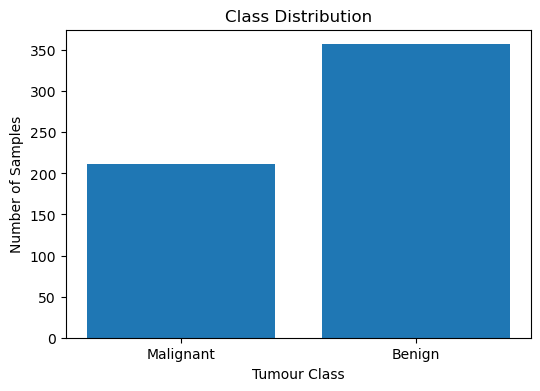

In [17]:
# Visualize class distribution

counts = y.value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(
    ['Malignant', 'Benign'],
    counts.values
)

plt.title("Class Distribution")
plt.xlabel("Tumour Class")
plt.ylabel("Number of Samples")
plt.show()


# 1.2 Checking for Null Values

Before building the model, we check whether any features contain missing values.


In [18]:
print(X.isnull().sum().sum())


0


If the output is **0**, there are no missing values in the dataset and no missing-value treatment is required.

# 1.3 Data Visualization

The dataset contains 30 features. We cannot visualize all 30 dimensions directly.

For teaching purposes, we will select two important features:

- `mean radius`
- `mean texture`

These two features allow us to create a simple 2D visualization.

### Important

The actual SVM models later will use **all 30 features**, not just these two visualization features.


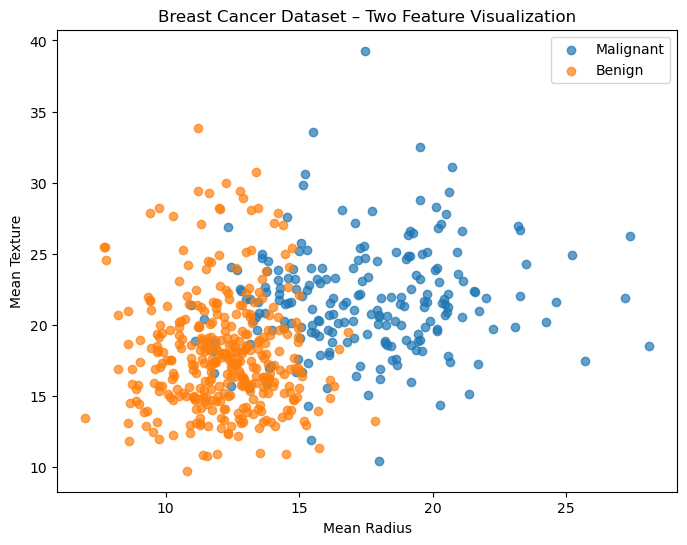

In [19]:
plt.figure(figsize=(8,6))

for target_value, label in [(0, 'Malignant'), (1, 'Benign')]:
    subset = X[y == target_value]

    plt.scatter(
        subset['mean radius'],
        subset['mean texture'],
        label=label,
        alpha=0.7
    )

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Breast Cancer Dataset – Two Feature Visualization")
plt.legend()
plt.show()


### Observation

The classes show some overlap.

This is important because real-world data is rarely perfectly separable.

SVM tries to find a decision boundary that separates the classes while maintaining a suitable margin.


# 1.4 Outlier Detection

We inspect the numerical features using boxplots.

Because there are 30 features, we display the first few features for teaching purposes.

We should not automatically remove observations simply because they appear as outliers. SVM can sometimes work with such observations, and removing them requires domain justification.


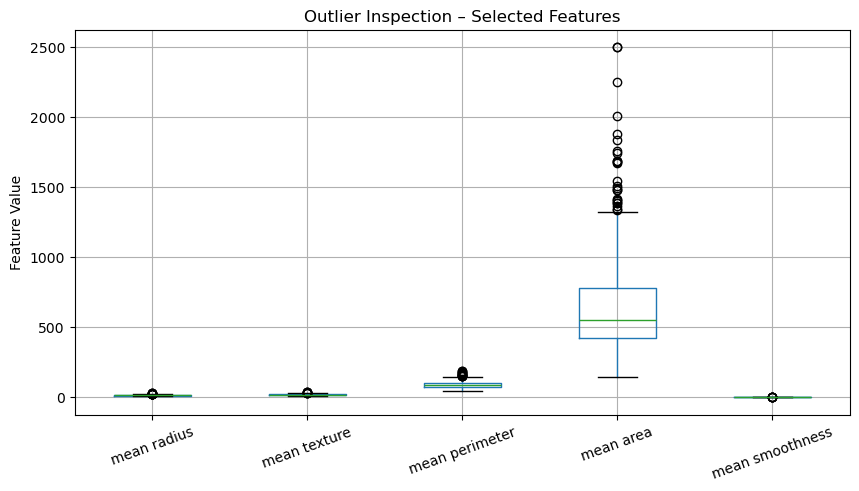

In [20]:
features_to_plot = [
    'mean radius',
    'mean texture',
    'mean perimeter',
    'mean area',
    'mean smoothness'
]

plt.figure(figsize=(10,5))
X[features_to_plot].boxplot()
plt.xticks(rotation=20)
plt.title("Outlier Inspection – Selected Features")
plt.ylabel("Feature Value")
plt.show()


# 1.5 Splitting Independent and Dependent Variables

### Independent Variables (X)

All 30 numerical features.

### Dependent Variable (y)

Tumour diagnosis:

- 0 → Malignant
- 1 → Benign


In [21]:
X = data.data
y = data.target

print("Number of features:", X.shape[1])
print("Number of observations:", X.shape[0])


Number of features: 30
Number of observations: 569


# 1.6 Train-Test Split

We divide the dataset into:

- **80% Training data**
- **20% Testing data**

The test data will remain unseen until final evaluation.

`stratify=y` keeps a similar class distribution in both sets.


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)


Training data: (455, 30)
Testing data : (114, 30)


# 1.7 Feature Scaling

SVM is sensitive to feature magnitude.

For example, `mean area` and `mean smoothness` have very different numerical ranges.

If features are not scaled, features with larger numerical values can have a disproportionate influence.

We use **Standardization**:

\[
z = \frac{x-\mu}{\sigma}
\]

### Important Rule

> **Split first → Fit the scaler only on training data → Transform both training and test data using the fitted scaler.**

This prevents data leakage.


In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")


Feature scaling completed.


# 2. Understanding SVM

**Support Vector Machine (SVM)** is a supervised machine learning algorithm mainly used for classification.

SVM tries to find a decision boundary that separates classes while maximizing the margin.

### Important Terms

**Hyperplane** → Decision boundary

**Margin** → Distance between the decision boundary and the closest data points

**Support Vectors** → Data points closest to the decision boundary

### Key Idea

> **SVM tries to find the maximum-margin decision boundary.**


# 3. Linear SVM

First, we build an SVM using the **Linear Kernel**.

```python
SVC(kernel='linear')
```

A linear SVM creates a linear decision boundary in the feature space.

It is a useful baseline model.


In [24]:
svm_linear = SVC(
    kernel='linear',
    C=1
)

svm_linear.fit(X_train_scaled, y_train)

print("Linear SVM trained successfully.")


Linear SVM trained successfully.


# 4. Polynomial SVM

The **Polynomial Kernel** can model polynomial relationships between the features.

Important parameters include:

- `C`
- `degree`
- `gamma`
- `coef0`

We start with:

`degree = 3`


In [25]:
svm_poly = SVC(
    kernel='poly',
    degree=3,
    C=1,
    gamma='scale'
)

svm_poly.fit(X_train_scaled, y_train)

print("Polynomial SVM trained successfully.")


Polynomial SVM trained successfully.


# 5. RBF SVM

The **RBF (Radial Basis Function)** kernel can model complex non-linear relationships.

Important parameters:

- `C`
- `gamma`

We start with the default `gamma='scale'`.


In [26]:
svm_rbf = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

svm_rbf.fit(X_train_scaled, y_train)

print("RBF SVM trained successfully.")


RBF SVM trained successfully.


# 6. Understanding Support Vectors

For the trained SVM models, Scikit-learn provides the support vectors through:

```python
model.support_vectors_
```

These are the training observations that are most important in defining the SVM boundary.


In [27]:
print("Number of support vectors – Linear SVM:",
      len(svm_linear.support_))

print("Number of support vectors – Polynomial SVM:",
      len(svm_poly.support_))

print("Number of support vectors – RBF SVM:",
      len(svm_rbf.support_))


Number of support vectors – Linear SVM: 32
Number of support vectors – Polynomial SVM: 145
Number of support vectors – RBF SVM: 97


# 7. Visualizing SVM Decision Boundaries

The dataset has 30 features, so we cannot directly draw the complete 30-dimensional decision boundary.

For visualization, we will use **two selected features only**:

- Mean Radius
- Mean Texture

This is purely for visual understanding.

### Important

The earlier models used **all 30 features**. The visualization below trains separate two-feature SVM models only for plotting.


In [28]:
# Select two features for visualization

X_vis = X[['mean radius', 'mean texture']]

X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(
    X_vis,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

vis_scaler = StandardScaler()

X_vis_train_scaled = vis_scaler.fit_transform(X_vis_train)
X_vis_test_scaled = vis_scaler.transform(X_vis_test)


In [29]:
# Train two-feature models for visualization

vis_linear = SVC(kernel='linear', C=1)
vis_poly = SVC(kernel='poly', degree=3, C=1, gamma='scale')
vis_rbf = SVC(kernel='rbf', C=1, gamma='scale')

vis_linear.fit(X_vis_train_scaled, y_vis_train)
vis_poly.fit(X_vis_train_scaled, y_vis_train)
vis_rbf.fit(X_vis_train_scaled, y_vis_train)


,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [30]:
def plot_decision_boundary(model, X, y, title):
    X_array = np.asarray(X)
    y_array = np.asarray(y)

    x_min, x_max = X_array[:, 0].min() - 1, X_array[:, 0].max() + 1
    y_min, y_max = X_array[:, 1].min() - 1, X_array[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7,5))

    plt.contourf(
        xx, yy, Z,
        alpha=0.20
    )

    plt.scatter(
        X_array[:, 0],
        X_array[:, 1],
        c=y_array,
        edgecolors='k',
        s=45
    )

    # Highlight support vectors
    if hasattr(model, 'support_vectors_'):
        sv = model.support_vectors_

        plt.scatter(
            sv[:, 0],
            sv[:, 1],
            facecolors='none',
            edgecolors='black',
            s=120,
            linewidths=1.5,
            label='Support Vectors'
        )

        plt.legend()

    plt.xlabel("Standardized Mean Radius")
    plt.ylabel("Standardized Mean Texture")
    plt.title(title)
    plt.show()


### Why are we using this plotting function?

This function is only for **visual learning**.

It creates a small grid over the two selected features and asks the trained model to predict each point in the grid.

The predicted regions show the decision boundary.

The highlighted circles represent the **support vectors**.

Unlike the previous notebook, this uses **only Matplotlib** and does not require `mlxtend`.


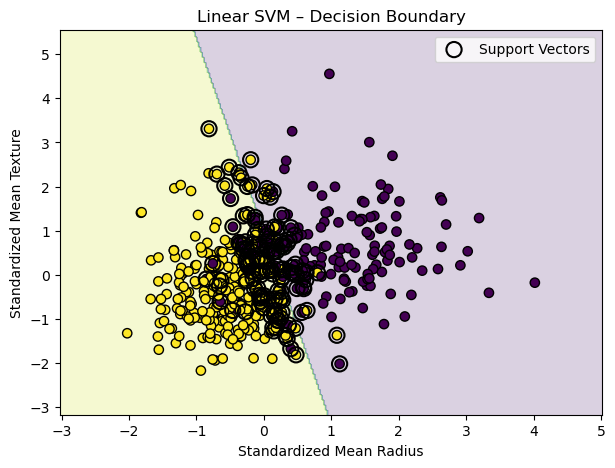

In [31]:
plot_decision_boundary(
    vis_linear,
    X_vis_train_scaled,
    y_vis_train,
    "Linear SVM – Decision Boundary"
)


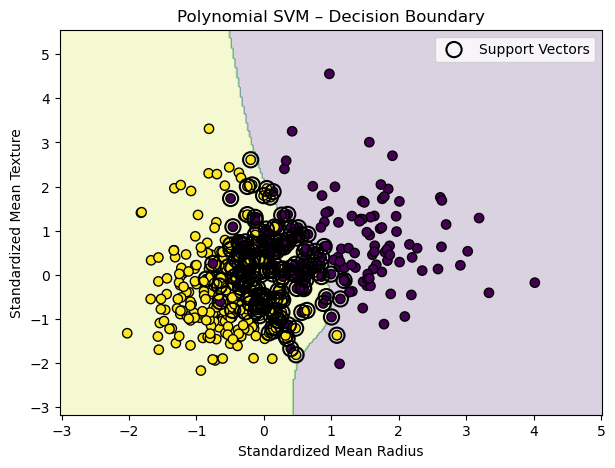

In [32]:
plot_decision_boundary(
    vis_poly,
    X_vis_train_scaled,
    y_vis_train,
    "Polynomial SVM – Decision Boundary"
)


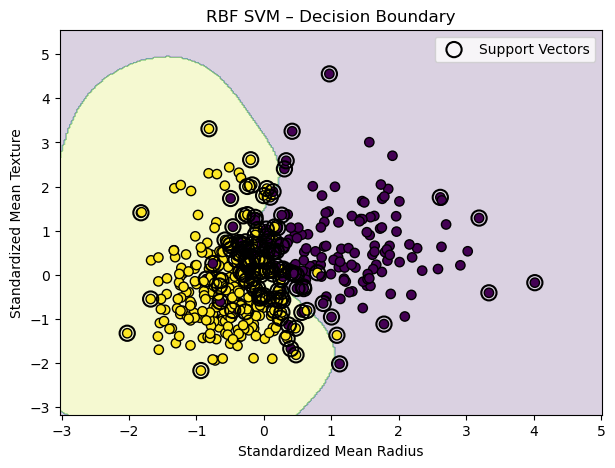

In [33]:
plot_decision_boundary(
    vis_rbf,
    X_vis_train_scaled,
    y_vis_train,
    "RBF SVM – Decision Boundary"
)


# 8. Kernel Comparison

### Linear Kernel
Creates a straight decision boundary.

### Polynomial Kernel
Can create a curved polynomial boundary.

### RBF Kernel
Can create a flexible non-linear boundary.

> **The kernel determines how SVM models relationships between observations.**


# 9. Why Not Transform the Data Directly?

Explicitly transforming every observation into a very high-dimensional feature space can be computationally expensive.

The **Kernel Trick** allows SVM to calculate the required relationship as if the data had been transformed, without explicitly creating all the transformed features.

\[
K(x,y)=\phi(x)\cdot\phi(y)
\]

> **The kernel gives SVM the benefit of a higher-dimensional representation without explicitly constructing that representation.**


# 10. C Parameter

**C controls how strongly SVM penalizes training errors.**

### Small C
- Allows more training errors.
- Gives the model more tolerance.
- Encourages a wider margin.
- May underfit if too small.

### Large C
- Penalizes training errors strongly.
- Tries harder to classify training samples correctly.
- Can produce a more complex boundary.
- May overfit if too large.

> **C controls how much SVM cares about training errors.**


# 11. Gamma Parameter

Gamma is especially important for the RBF kernel.

It controls how strongly an individual training point influences the decision boundary.

### Small Gamma
- Wider influence.
- Smoother boundary.
- Simpler model.
- May underfit.

### Large Gamma
- More local influence.
- More complex boundary.
- May overfit.

> **Gamma controls how sensitive the model is to individual data points.**


# 12. Degree Parameter

`degree` is used by the Polynomial Kernel.

- Degree 2 → quadratic
- Degree 3 → cubic
- Degree 4 → higher-order polynomial

Higher degree can make the decision boundary more complex and may increase the risk of overfitting.


# 13. coef0 Parameter

`coef0` is relevant to the **Polynomial and Sigmoid kernels**.

It controls the influence of the independent constant term in the kernel calculation.

For this practical, we keep the default value and focus mainly on **C, gamma and degree**.


# 14. Testing the Models

Now we use the unseen test data to evaluate the three models trained using **all 30 features**.

In [34]:
y_pred_linear = svm_linear.predict(X_test_scaled)
y_pred_poly = svm_poly.predict(X_test_scaled)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

print("Predictions generated successfully.")


Predictions generated successfully.


# 15. Evaluation of SVM Models

We compare:

- Accuracy
- Precision
- Recall
- F1-score


In [29]:
def evaluate_model(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate_model("Linear SVM", y_test, y_pred_linear),
    evaluate_model("Polynomial SVM", y_test, y_pred_poly),
    evaluate_model("RBF SVM", y_test, y_pred_rbf)
])

results


,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.973684,0.985915,0.972222,0.979021
1,Polynomial SVM,0.912281,0.878049,1.000000,0.935065
2,RBF SVM,0.982456,0.986111,0.986111,0.986111


# 16. Hyperparameter Tuning using GridSearchCV

We will tune:

- Kernel
- C
- Gamma
- Degree

### Why GridSearchCV?

Instead of manually testing many combinations, GridSearchCV systematically evaluates the combinations we provide.

We use a **Pipeline** so that scaling is performed correctly inside each cross-validation fold.

### cv=5

The training data is divided into 5 folds.

Each fold gets a turn as the validation fold while the other four folds are used for training.


In [36]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])


param_grid = {
    'svm__kernel': ['linear', 'poly', 'rbf'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__degree': [2, 3, 4],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1]
}


grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search.best_score_)


Best Parameters:
{'svm__C': 10, 'svm__degree': 2, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

Best Cross-Validation Score:
0.9802197802197803


 Kernel Comparison

| Kernel | Decision Boundary | Main Parameters | Typical Use |
|---|---|---|---|
| **Linear** | Straight | C | Approximately linear relationships |
| **Polynomial** | Polynomial/curved | C, degree, gamma, coef0 | Polynomial relationships |
| **RBF** | Flexible non-linear | C, gamma | Complex non-linear relationships |

### Easy way to remember

**Linear → Straight**

**Polynomial → Curved polynomial**

**RBF → Flexible non-linear**


# Student Questions

### Q1. Why is feature scaling important for SVM?
Because SVM is affected by feature magnitude and distance/kernel calculations.

### Q2. What is the role of the support vectors?
They are the observations closest to the decision boundary and strongly influence the SVM boundary.

### Q3. What happens when C is very small?
The model allows more training errors and may underfit.

### Q4. What happens when C is very large?
The model strongly penalizes errors and may become more complex.

### Q5. What happens when gamma is very large?
The RBF model becomes highly sensitive to individual observations and may overfit.

### Q6. Which kernel creates a straight boundary?
Linear kernel.

### Q7. Which kernel is commonly used for complex non-linear relationships?
RBF kernel.

### Q8. What does degree control?
The complexity of the Polynomial kernel.

### Q9. Why do we use GridSearchCV?
To systematically find a good combination of hyperparameters using cross-validation.

### Q10. Why should scaling be inside the Pipeline during GridSearchCV?
To ensure the scaler is fitted only on the training portion of each cross-validation fold and prevent data leakage.


# Final Takeaways

1. **SVM is a supervised classification algorithm.**
2. It tries to find a **maximum-margin decision boundary**.
3. The closest observations are called **support vectors**.
4. Feature scaling is important for SVM.
5. **Linear kernel → straight boundary.**
6. **Polynomial kernel → polynomial boundary.**
7. **RBF kernel → flexible non-linear boundary.**
8. **C → controls the penalty for training errors.**
9. **Gamma → controls the influence of individual points in RBF.**
10. **Degree → controls Polynomial kernel complexity.**
11. **coef0 → affects Polynomial and Sigmoid kernels.**
12. GridSearchCV can tune SVM hyperparameters.
13. The test set should remain unseen until final evaluation.


In [30]:
from sklearn.linear_model import LogisticRegression 
lg = LogisticRegression(max_iter=1000)
lg.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [31]:
y_pred_lg = lg.predict(X_test_scaled)
lgd = evaluate_model('Logistic',y_test,y_pred_lg)

In [32]:
from sklearn.neighbors import KNeighborsClassifier 
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [33]:
y_pred_knn = knn.predict(X_test_scaled)
knnd = evaluate_model('KNN',y_test,y_pred_knn)

In [34]:
from sklearn.naive_bayes import GaussianNB 
nb = GaussianNB()
nb.fit(X_train_scaled,y_train)

,priors,None
,var_smoothing,1e-09


In [35]:
y_pred_nb = knn.predict(X_test_scaled)
nbgd = evaluate_model('Naive Bayes G',y_test,y_pred_nb)

In [36]:
results = pd.DataFrame([
    evaluate_model("Linear SVM", y_test, y_pred_linear),
    evaluate_model("Polynomial SVM", y_test, y_pred_poly),
    evaluate_model("RBF SVM", y_test, y_pred_rbf), 
    lgd , knnd , nbgd
])

In [37]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.973684,0.985915,0.972222,0.979021
1,Polynomial SVM,0.912281,0.878049,1.000000,0.935065
2,RBF SVM,0.982456,0.986111,0.986111,0.986111
3,Logistic,0.982456,0.986111,0.986111,0.986111
4,KNN,0.956140,0.958904,0.972222,0.965517
5,Naive Bayes G,0.956140,0.958904,0.972222,0.965517
